# 04 — DREAMER Preprocessing Pipeline
**Project:** Quantum Machine Learning for Physiological Stress Classification  
**Author:** Kenza Qribis

---

## Purpose
Transform raw DREAMER EEG and ECG signals into a clean, model-ready feature matrix.
Each stimulus recording (one film clip per subject) becomes one feature vector.

## Feature Groups Extracted
1. **EEG Band Power** — delta/theta/alpha/beta/gamma per channel (14 ch x 5 bands = 70 features)
2. **Frontal Asymmetry** — DASM and RASM at F3/F4 (2 features, key for valence discrimination)
3. **Statistical Moments** — mean, variance, skewness, kurtosis per band per channel (4 x 5 x 14 = 280, reduced by selection)
4. **ECG/HRV Features** — mean HR, SDNN, RMSSD from ECG channels

## Label Strategy
- **Binary:** arousal > 3 = high/stress-proxy (1), arousal <= 3 = calm (0)
- Valence ratings preserved as metadata for overlap analysis

## No Data Leakage
As with WESAD: normalization and PCA are fitted per LOSO fold inside modeling notebooks.
This notebook only extracts raw features.

---
> Set `DREAMER_PATH` in Section 0 before running.


## 0. Configuration

In [1]:
import os, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from datetime import datetime
from scipy.io import loadmat
from scipy import signal as scipy_signal
from scipy.stats import skew, kurtosis

warnings.filterwarnings('ignore')

# ── SET THIS ──────────────────────────────────────────────────────────────────
DREAMER_PATH = r"C:/Users/ACER/Desktop/APPLIED RESEARCH/Applied-Research/data/DREAMER/DREAMER.mat"
# ─────────────────────────────────────────────────────────────────────────────

RESULTS_ROOT    = os.path.join('..', 'results')
PLOTS_DIR       = os.path.join(RESULTS_ROOT, 'plots', '04_dreamer_preprocessing')
LOGS_DIR        = os.path.join(RESULTS_ROOT, 'logs')
OUTPUT_DATA_DIR = os.path.join(RESULTS_ROOT, 'output_data')
for d in [PLOTS_DIR, LOGS_DIR, OUTPUT_DATA_DIR]:
    os.makedirs(d, exist_ok=True)

# ── Dataset constants ─────────────────────────────────────────────────────────
N_SUBJECTS  = 23
N_VIDEOS    = 18
FS_EEG      = 128
FS_ECG      = 256
N_EEG_CH    = 14

EEG_CHANNELS = ['AF3','F7','F3','FC5','T7','P7','O1','O2','P8','T8','FC6','F4','F8','AF4']
F3_IDX = 2
F4_IDX = 11

BANDS = {
    'delta': (1,   4),
    'theta': (4,   8),
    'alpha': (8,  13),
    'beta' : (13, 30),
    'gamma': (30, 45)
}

AROUSAL_THRESHOLD = 3

plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.size']  = 11
sns.set_style('whitegrid')

print('Configuration ready.')
print(f'  DREAMER path    : {DREAMER_PATH}')
print(f'  Output data dir : {os.path.abspath(OUTPUT_DATA_DIR)}')
print(f'  Plots dir       : {os.path.abspath(PLOTS_DIR)}')


Configuration ready.
  DREAMER path    : C:/Users/ACER/Desktop/APPLIED RESEARCH/Applied-Research/data/DREAMER/DREAMER.mat
  Output data dir : c:\Users\ACER\Desktop\APPLIED RESEARCH\Applied-Research\results\output_data
  Plots dir       : c:\Users\ACER\Desktop\APPLIED RESEARCH\Applied-Research\results\plots\04_dreamer_preprocessing


## 1. Load DREAMER

In [2]:
print('Loading DREAMER.mat...')
mat      = loadmat(DREAMER_PATH, simplify_cells=True)
dreamer  = mat['DREAMER']
data_all = dreamer['Data']
print(f'Loaded. {len(data_all)} subjects found.')


Loading DREAMER.mat...
Loaded. 23 subjects found.


## 2. Helper Functions

In [3]:
def orient_eeg(arr):
    """Ensure EEG array is (samples, channels)."""
    arr = np.array(arr, dtype=float)
    if arr.ndim == 1:
        return arr.reshape(-1, 1)
    if arr.shape[0] < arr.shape[1]:
        arr = arr.T
    return arr


def get_ratings(subject_data):
    """Extract valence, arousal, dominance — handles key variants."""
    def find_key(d, candidates):
        for c in candidates:
            if c in d:
                return np.array(d[c]).flatten()
        return np.full(N_VIDEOS, np.nan)
    val = find_key(subject_data, ['Valence','valence','val'])
    aro = find_key(subject_data, ['Arousal','arousal','aro'])
    dom = find_key(subject_data, ['Dominance','dominance','dom'])
    return val, aro, dom


def band_power(sig, fs, fmin, fmax):
    """Compute power in frequency band using Welch's method."""
    nperseg = min(fs * 2, len(sig))
    freqs, psd = scipy_signal.welch(sig, fs=fs, nperseg=nperseg)
    idx = (freqs >= fmin) & (freqs <= fmax)
    if idx.sum() == 0:
        return 0.0
    return float(np.trapz(psd[idx], freqs[idx]))


def notch_filter(sig, fs, freq=50.0, Q=30.0):
    """Remove powerline noise (50 Hz Europe)."""
    b, a = scipy_signal.iirnotch(freq, Q, fs)
    return scipy_signal.filtfilt(b, a, sig)


def bandpass_eeg(sig, fs=128, lowcut=1.0, highcut=45.0, order=4):
    """Bandpass filter for EEG: 1–45 Hz."""
    nyq = fs / 2
    b, a = scipy_signal.butter(order, [lowcut/nyq, highcut/nyq], btype='band')
    return scipy_signal.filtfilt(b, a, sig)


print('Helper functions defined.')


Helper functions defined.


## 3. EEG Feature Extraction Functions

In [4]:
def extract_eeg_band_features(eeg, fs=128):
    """
    Extract band power features from an EEG recording.
    eeg : array (samples, n_channels)
    Returns dict of features.
    """
    feats = {}
    n_ch  = eeg.shape[1] if eeg.ndim > 1 else 1

    for ch_idx in range(min(n_ch, N_EEG_CH)):
        ch_name = EEG_CHANNELS[ch_idx] if ch_idx < len(EEG_CHANNELS) else f'ch{ch_idx}'
        sig = eeg[:, ch_idx] if eeg.ndim > 1 else eeg

        # Filter: bandpass 1-45 Hz + notch 50 Hz
        try:
            sig = bandpass_eeg(sig, fs)
            if fs >= 100:
                sig = notch_filter(sig, fs)
        except Exception:
            pass

        # Band power
        for band, (fmin, fmax) in BANDS.items():
            bp = band_power(sig, fs, fmin, fmax)
            feats[f'{ch_name}_{band}_power'] = bp

        # Statistical moments per channel
        feats[f'{ch_name}_mean']     = float(np.mean(sig))
        feats[f'{ch_name}_variance'] = float(np.var(sig))
        feats[f'{ch_name}_skew']     = float(skew(sig))
        feats[f'{ch_name}_kurt']     = float(kurtosis(sig))

    return feats


def extract_frontal_asymmetry(eeg, fs=128):
    """
    Compute DASM and RASM from F3 (idx 2) and F4 (idx 11).
    These are the key valence-discriminating features.
    Negative DASM = left frontal alpha suppression = negative affect (stress).
    """
    feats = {}
    if eeg.ndim < 2 or eeg.shape[1] <= max(F3_IDX, F4_IDX):
        for k in ['f3_alpha','f4_alpha','dasm_alpha','rasm_alpha',
                  'dasm_beta','rasm_beta','dasm_theta','rasm_theta']:
            feats[k] = np.nan
        return feats

    f3 = eeg[:, F3_IDX]
    f4 = eeg[:, F4_IDX]

    try:
        f3 = bandpass_eeg(f3, fs)
        f4 = bandpass_eeg(f4, fs)
    except Exception:
        pass

    # Alpha asymmetry (primary — valence discrimination)
    f3_alpha = band_power(f3, fs, 8, 13)
    f4_alpha = band_power(f4, fs, 8, 13)
    feats['f3_alpha']    = f3_alpha
    feats['f4_alpha']    = f4_alpha
    feats['dasm_alpha']  = f3_alpha - f4_alpha
    feats['rasm_alpha']  = f4_alpha / (f3_alpha + 1e-10)

    # Beta asymmetry (secondary)
    f3_beta = band_power(f3, fs, 13, 30)
    f4_beta = band_power(f4, fs, 13, 30)
    feats['dasm_beta']   = f3_beta - f4_beta
    feats['rasm_beta']   = f4_beta / (f3_beta + 1e-10)

    # Theta asymmetry
    f3_theta = band_power(f3, fs, 4, 8)
    f4_theta = band_power(f4, fs, 4, 8)
    feats['dasm_theta']  = f3_theta - f4_theta
    feats['rasm_theta']  = f4_theta / (f3_theta + 1e-10)

    return feats


def extract_ecg_features_dreamer(ecg, fs=256):
    """
    Basic HRV features from DREAMER ECG.
    Uses channel 0 (Lead I equivalent).
    Falls back to signal statistics if R-peak detection fails.
    """
    feats = {}
    try:
        import neurokit2 as nk
        ecg_arr = np.array(ecg, dtype=float)
        if ecg_arr.ndim > 1:
            ecg_arr = ecg_arr[:, 0] if ecg_arr.shape[1] <= ecg_arr.shape[0] \
                      else ecg_arr[0, :]

        _, info = nk.ecg_process(ecg_arr, sampling_rate=fs)
        hrv     = nk.hrv_time(info['ECG_R_Peaks'], sampling_rate=fs, show=False)
        rpeaks  = info['ECG_R_Peaks']

        if len(rpeaks) < 2:
            raise ValueError('Too few R-peaks')

        rr_ms = np.diff(rpeaks) / fs * 1000
        feats['ecg_mean_hr']  = float(60000 / np.mean(rr_ms))
        feats['ecg_sdnn']     = float(hrv['HRV_SDNN'].iloc[0])
        feats['ecg_rmssd']    = float(hrv['HRV_RMSSD'].iloc[0])
        feats['ecg_pnn50']    = float(hrv['HRV_pNN50'].iloc[0])
        feats['ecg_mean_rr']  = float(np.mean(rr_ms))
    except Exception:
        # Fallback: raw signal statistics
        ecg_arr = np.array(ecg, dtype=float).flatten()
        feats['ecg_mean_hr']  = np.nan
        feats['ecg_sdnn']     = float(np.std(ecg_arr))
        feats['ecg_rmssd']    = np.nan
        feats['ecg_pnn50']    = np.nan
        feats['ecg_mean_rr']  = np.nan
    return feats


print('Feature extraction functions defined.')
print('Features per recording:')
print(f'  EEG band power   : {N_EEG_CH} channels x 5 bands = {N_EEG_CH*5} features')
print(f'  EEG stat moments : {N_EEG_CH} channels x 4 stats = {N_EEG_CH*4} features')
print(f'  Frontal asymmetry: 8 features (DASM/RASM for alpha/beta/theta + F3/F4 raw)')
print(f'  ECG/HRV          : 5 features')
print(f'  TOTAL approx     : {N_EEG_CH*5 + N_EEG_CH*4 + 8 + 5} features')


Feature extraction functions defined.
Features per recording:
  EEG band power   : 14 channels x 5 bands = 70 features
  EEG stat moments : 14 channels x 4 stats = 56 features
  Frontal asymmetry: 8 features (DASM/RASM for alpha/beta/theta + F3/F4 raw)
  ECG/HRV          : 5 features
  TOTAL approx     : 139 features


## 4. Run Feature Extraction on All Subjects
> Each recording = one film clip stimulus for one subject.
> 23 subjects x 18 videos = 414 recordings total.

In [5]:
from tqdm.notebook import tqdm

all_rows = []
failed   = []

print('Extracting features from all subjects...')

for sid in tqdm(range(N_SUBJECTS), desc='Subjects'):
    s = data_all[sid]
    val, aro, dom = get_ratings(s)
    eeg_stimuli = s['EEG']['stimuli']
    ecg_stimuli = s['ECG']['stimuli']

    for vid in range(len(eeg_stimuli)):
        try:
            # Orient EEG
            eeg = orient_eeg(eeg_stimuli[vid])
            if eeg.shape[1] != N_EEG_CH:
                # Try transpose
                eeg = eeg.T
            if eeg.shape[1] != N_EEG_CH:
                raise ValueError(f'Unexpected EEG shape: {eeg.shape}')

            # Get ratings
            aro_v = float(aro[vid]) if vid < len(aro) else np.nan
            val_v = float(val[vid]) if vid < len(val) else np.nan
            dom_v = float(dom[vid]) if vid < len(dom) else np.nan

            # Build row
            row = {
                'subject_id'      : sid + 1,
                'video_id'        : vid + 1,
                'valence'         : val_v,
                'arousal'         : aro_v,
                'dominance'       : dom_v,
                'arousal_binary'  : int(aro_v > AROUSAL_THRESHOLD)
                                    if not np.isnan(aro_v) else np.nan,
                'valence_binary'  : int(val_v > AROUSAL_THRESHOLD)
                                    if not np.isnan(val_v) else np.nan,
            }

            # Extract EEG features
            row.update(extract_eeg_band_features(eeg, FS_EEG))
            row.update(extract_frontal_asymmetry(eeg, FS_EEG))

            # Extract ECG features
            if vid < len(ecg_stimuli):
                row.update(extract_ecg_features_dreamer(ecg_stimuli[vid], FS_ECG))
            else:
                for k in ['ecg_mean_hr','ecg_sdnn','ecg_rmssd','ecg_pnn50','ecg_mean_rr']:
                    row[k] = np.nan

            all_rows.append(row)

        except Exception as e:
            failed.append({'subject': sid+1, 'video': vid+1, 'error': str(e)})

df_dreamer = pd.DataFrame(all_rows)
print(f'\nDone.')
print(f'  Total recordings  : {len(df_dreamer)}')
print(f'  Feature columns   : {len(df_dreamer.columns)}')
print(f'  Failed            : {len(failed)}')
if failed:
    for f in failed[:5]:
        print(f'    {f}')

print('\nLabel distribution (arousal_binary):')
for k, v in sorted(Counter(df_dreamer['arousal_binary'].dropna().astype(int)).items()):
    name = 'high arousal (stress-proxy)' if k==1 else 'low arousal (calm)'
    print(f'  {k} ({name}): {v} ({100*v/len(df_dreamer):.1f}%)')


Extracting features from all subjects...


Subjects:   0%|          | 0/23 [00:00<?, ?it/s]


Done.
  Total recordings  : 414
  Feature columns   : 146
  Failed            : 0

Label distribution (arousal_binary):


## 5. Handle Missing Values

In [6]:
meta_cols    = ['subject_id','video_id','valence','arousal','dominance',
                'arousal_binary','valence_binary']
feature_cols = [c for c in df_dreamer.columns if c not in meta_cols]

nan_counts = df_dreamer[feature_cols].isna().sum()
nan_cols   = nan_counts[nan_counts > 0]

print('=== Missing Value Summary ===')
if len(nan_cols) == 0:
    print('  No missing values in feature columns.')
else:
    print(f'  {len(nan_cols)} features with NaN:')
    print(nan_cols[nan_cols > 0].to_string())
    total_nan = df_dreamer[feature_cols].isna().sum().sum()
    pct = total_nan / (len(df_dreamer) * len(feature_cols)) * 100
    print(f'  Total NaN cells: {total_nan}  ({pct:.2f}%)')

# Per-subject median imputation
if len(nan_cols) > 0:
    print('\nApplying per-subject median imputation...')
    for sid in df_dreamer['subject_id'].unique():
        mask = df_dreamer['subject_id'] == sid
        df_dreamer.loc[mask, feature_cols] = (
            df_dreamer.loc[mask, feature_cols]
            .fillna(df_dreamer.loc[mask, feature_cols].median())
        )
    # Global fallback
    df_dreamer[feature_cols] = df_dreamer[feature_cols].fillna(
        df_dreamer[feature_cols].median())
    remaining = df_dreamer[feature_cols].isna().sum().sum()
    print(f'  Remaining NaN after imputation: {remaining}')

print(f'\nFinal feature count : {len(feature_cols)}')
print(f'Final dataset shape : {df_dreamer.shape}')


=== Missing Value Summary ===
  No missing values in feature columns.

Final feature count : 139
Final dataset shape : (414, 146)


## 6. Feature Distribution Plots

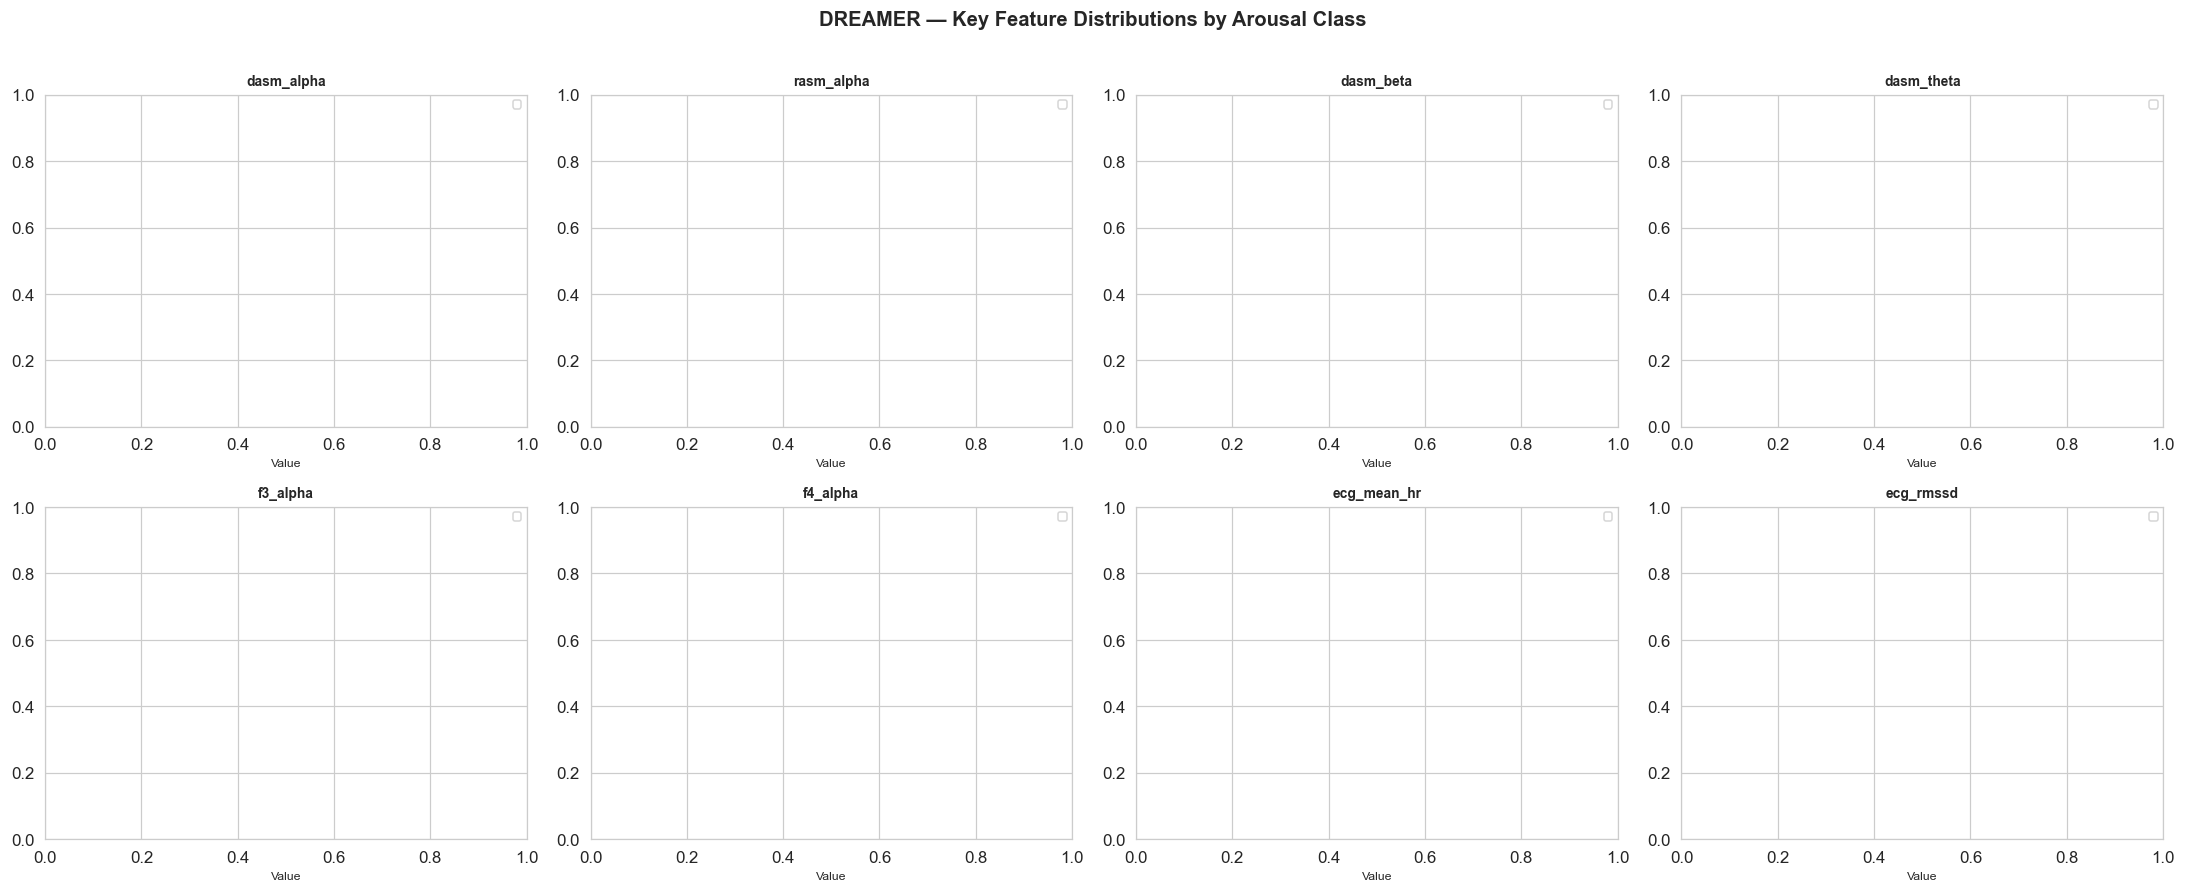

Saved: ..\results\plots\04_dreamer_preprocessing\feature_distributions_by_arousal.png


In [7]:
# Key features to visualize
key_feats = ['dasm_alpha','rasm_alpha','dasm_beta','dasm_theta',
             'f3_alpha','f4_alpha','ecg_mean_hr','ecg_rmssd']
key_feats = [f for f in key_feats if f in df_dreamer.columns]

n_cols = 4
n_rows = int(np.ceil(len(key_feats) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4*n_rows))
axes = axes.flatten()

colors = {0: '#4CAF50', 1: '#F44336'}
names  = {0: 'Low arousal (calm)', 1: 'High arousal (stress-proxy)'}

for i, feat in enumerate(key_feats):
    ax = axes[i]
    for bl in [0, 1]:
        mask = df_dreamer['arousal_binary'] == bl
        vals = df_dreamer.loc[mask, feat].dropna()
        if len(vals) > 0:
            ax.hist(vals, bins=30, alpha=0.6, color=colors[bl],
                    label=names[bl], density=True)
    ax.set_title(feat, fontweight='bold', fontsize=9)
    ax.set_xlabel('Value', fontsize=8)
    ax.legend(fontsize=7)

for j in range(len(key_feats), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('DREAMER — Key Feature Distributions by Arousal Class',
             fontweight='bold', y=1.01)
plt.tight_layout()
p = os.path.join(PLOTS_DIR, 'feature_distributions_by_arousal.png')
plt.savefig(p, bbox_inches='tight'); plt.show()
print(f'Saved: {p}')


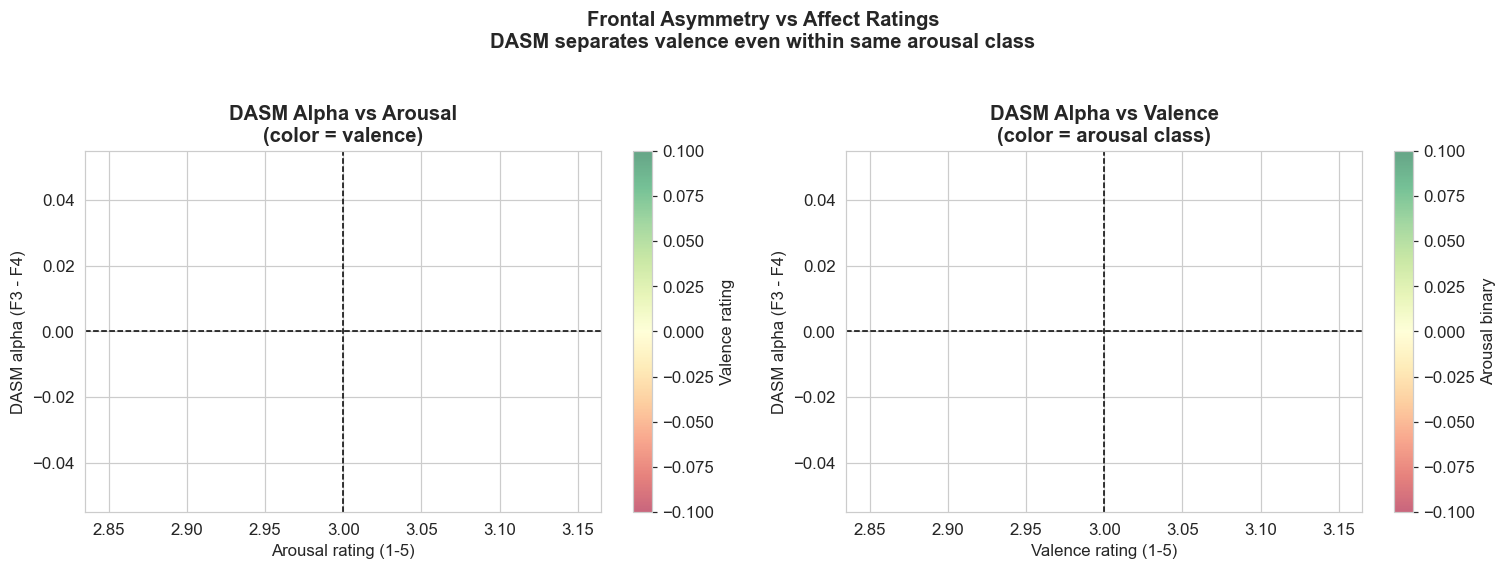

Saved: ..\results\plots\04_dreamer_preprocessing\dasm_vs_affect_ratings.png


In [8]:
# DASM vs Valence scatter — the key overlap plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# DASM alpha vs arousal rating
if 'dasm_alpha' in df_dreamer.columns:
    sc = axes[0].scatter(
        df_dreamer['arousal'], df_dreamer['dasm_alpha'],
        c=df_dreamer['valence'], cmap='RdYlGn',
        alpha=0.6, s=30)
    plt.colorbar(sc, ax=axes[0], label='Valence rating')
    axes[0].axhline(0, color='black', linestyle='--', lw=1)
    axes[0].axvline(AROUSAL_THRESHOLD, color='black', linestyle='--', lw=1)
    axes[0].set_xlabel('Arousal rating (1-5)')
    axes[0].set_ylabel('DASM alpha (F3 - F4)')
    axes[0].set_title('DASM Alpha vs Arousal\n(color = valence)',
                      fontweight='bold')

# DASM alpha vs valence rating
if 'dasm_alpha' in df_dreamer.columns:
    sc2 = axes[1].scatter(
        df_dreamer['valence'], df_dreamer['dasm_alpha'],
        c=df_dreamer['arousal_binary'], cmap='RdYlGn',
        alpha=0.6, s=30)
    plt.colorbar(sc2, ax=axes[1], label='Arousal binary')
    axes[1].axhline(0, color='black', linestyle='--', lw=1)
    axes[1].axvline(AROUSAL_THRESHOLD, color='black', linestyle='--', lw=1)
    axes[1].set_xlabel('Valence rating (1-5)')
    axes[1].set_ylabel('DASM alpha (F3 - F4)')
    axes[1].set_title('DASM Alpha vs Valence\n(color = arousal class)',
                      fontweight='bold')

plt.suptitle('Frontal Asymmetry vs Affect Ratings\n'
             'DASM separates valence even within same arousal class',
             fontweight='bold', y=1.03)
plt.tight_layout()
p = os.path.join(PLOTS_DIR, 'dasm_vs_affect_ratings.png')
plt.savefig(p, bbox_inches='tight'); plt.show()
print(f'Saved: {p}')


## 7. LOSO Structure for DREAMER
DREAMER uses subject-level LOSO — same protocol as WESAD.

In [9]:
dreamer_subjects = sorted(df_dreamer['subject_id'].unique().tolist())
print('=== DREAMER LOSO Structure ===')
print(f'  Subjects : {len(dreamer_subjects)}')
print(f'  Folds    : {len(dreamer_subjects)}')
print(f'  Per fold : train on {len(dreamer_subjects)-1}, test on 1')
print()

loso_log = []
for i, test_sid in enumerate(dreamer_subjects):
    train = [s for s in dreamer_subjects if s != test_sid]
    loso_log.append({'fold': i+1, 'test': int(test_sid),
                     'train': [int(s) for s in train]})
    print(f'  Fold {i+1:2d}: test=S{test_sid:2d}  '
          f'train_n={len(train)}  '
          f'test_recordings={len(df_dreamer[df_dreamer["subject_id"]==test_sid])}')

p = os.path.join(LOGS_DIR, 'dreamer_loso_fold_structure.json')
with open(p,'w') as f: json.dump(loso_log, f, indent=2)
print(f'\nSaved: {p}')


=== DREAMER LOSO Structure ===
  Subjects : 23
  Folds    : 23
  Per fold : train on 22, test on 1

  Fold  1: test=S 1  train_n=22  test_recordings=18
  Fold  2: test=S 2  train_n=22  test_recordings=18
  Fold  3: test=S 3  train_n=22  test_recordings=18
  Fold  4: test=S 4  train_n=22  test_recordings=18
  Fold  5: test=S 5  train_n=22  test_recordings=18
  Fold  6: test=S 6  train_n=22  test_recordings=18
  Fold  7: test=S 7  train_n=22  test_recordings=18
  Fold  8: test=S 8  train_n=22  test_recordings=18
  Fold  9: test=S 9  train_n=22  test_recordings=18
  Fold 10: test=S10  train_n=22  test_recordings=18
  Fold 11: test=S11  train_n=22  test_recordings=18
  Fold 12: test=S12  train_n=22  test_recordings=18
  Fold 13: test=S13  train_n=22  test_recordings=18
  Fold 14: test=S14  train_n=22  test_recordings=18
  Fold 15: test=S15  train_n=22  test_recordings=18
  Fold 16: test=S16  train_n=22  test_recordings=18
  Fold 17: test=S17  train_n=22  test_recordings=18
  Fold 18: test=

## 8. Save Datasets

In [10]:
# Full DREAMER feature matrix
p_full = os.path.join(OUTPUT_DATA_DIR, 'dreamer_features_all.csv')
df_dreamer.to_csv(p_full, index=False)
print(f'Saved full dataset     : {p_full}')

# Binary arousal dataset (drop NaN labels)
df_binary = df_dreamer.dropna(subset=['arousal_binary']).copy()
df_binary['arousal_binary'] = df_binary['arousal_binary'].astype(int)
p_bin = os.path.join(OUTPUT_DATA_DIR, 'dreamer_features_binary.csv')
df_binary.to_csv(p_bin, index=False)
print(f'Saved binary dataset   : {p_bin}')
print(f'  Shape: {df_binary.shape}')
print(f'  Class 0 (calm)        : {(df_binary["arousal_binary"]==0).sum()}')
print(f'  Class 1 (stress-proxy): {(df_binary["arousal_binary"]==1).sum()}')

# Save feature column list
meta_cols    = ['subject_id','video_id','valence','arousal','dominance',
                'arousal_binary','valence_binary']
feature_cols = [c for c in df_dreamer.columns if c not in meta_cols]
p_feat = os.path.join(OUTPUT_DATA_DIR, 'dreamer_feature_columns.json')
with open(p_feat,'w') as f: json.dump(feature_cols, f, indent=2)
print(f'Saved feature columns  : {p_feat}')
print(f'  Total features: {len(feature_cols)}')


Saved full dataset     : ..\results\output_data\dreamer_features_all.csv
Saved binary dataset   : ..\results\output_data\dreamer_features_binary.csv
  Shape: (0, 146)
  Class 0 (calm)        : 0
  Class 1 (stress-proxy): 0
Saved feature columns  : ..\results\output_data\dreamer_feature_columns.json
  Total features: 139


## 9. Cross-Dataset Alignment Check
Verify that WESAD and DREAMER feature spaces overlap sufficiently for cross-dataset experiments.

In [11]:
# Load WESAD feature columns from notebook 02
wesad_feat_path = os.path.join(OUTPUT_DATA_DIR, 'feature_columns.json')
if os.path.exists(wesad_feat_path):
    with open(wesad_feat_path) as f:
        wesad_cols = json.load(f)
    dreamer_cols = feature_cols

    shared = set(wesad_cols) & set(dreamer_cols)
    wesad_only   = set(wesad_cols) - set(dreamer_cols)
    dreamer_only = set(dreamer_cols) - set(wesad_cols)

    print('=== Cross-Dataset Feature Alignment ===')
    print(f'  WESAD features   : {len(wesad_cols)}')
    print(f'  DREAMER features : {len(dreamer_cols)}')
    print(f'  Shared features  : {len(shared)}')
    print(f'  WESAD only       : {len(wesad_only)}')
    print(f'  DREAMER only     : {len(dreamer_only)}')

    if len(shared) > 0:
        print(f'\n  Shared: {sorted(shared)}')

    print('\nNOTE: Cross-dataset experiments will use only shared features.')
    print('      ECG-derived HRV features (mean_hr, sdnn, rmssd) appear in both.')

    # Save shared feature list
    p_shared = os.path.join(OUTPUT_DATA_DIR, 'shared_feature_columns.json')
    with open(p_shared,'w') as f: json.dump(sorted(shared), f, indent=2)
    print(f'\nSaved shared features: {p_shared}')
else:
    print('WESAD feature_columns.json not found.')
    print('Run notebook 02 first, then re-run this cell.')


=== Cross-Dataset Feature Alignment ===
  WESAD features   : 26
  DREAMER features : 139
  Shared features  : 5
  WESAD only       : 21
  DREAMER only     : 134

  Shared: ['ecg_mean_hr', 'ecg_mean_rr', 'ecg_pnn50', 'ecg_rmssd', 'ecg_sdnn']

NOTE: Cross-dataset experiments will use only shared features.
      ECG-derived HRV features (mean_hr, sdnn, rmssd) appear in both.

Saved shared features: ..\results\output_data\shared_feature_columns.json


## 10. Summary Log

In [12]:
arousal_dist = {str(k): int(v) for k,v in
                Counter(df_binary['arousal_binary']).items()}

summary = {
    'notebook'         : '04_dreamer_preprocessing',
    'timestamp'        : datetime.now().isoformat(),
    'dreamer_path'     : DREAMER_PATH,
    'n_subjects'       : N_SUBJECTS,
    'total_recordings' : int(len(df_dreamer)),
    'total_features'   : len(feature_cols),
    'feature_groups': {
        'eeg_band_power'     : f'{N_EEG_CH} channels x 5 bands',
        'eeg_stat_moments'   : f'{N_EEG_CH} channels x 4 stats',
        'frontal_asymmetry'  : '8 (DASM/RASM alpha/beta/theta + F3/F4 raw)',
        'ecg_hrv'            : '5 (mean_hr, sdnn, rmssd, pnn50, mean_rr)'
    },
    'binary_task': {
        'total'        : int(len(df_binary)),
        'label_dist'   : arousal_dist,
        'binarization' : f'arousal > {AROUSAL_THRESHOLD} -> 1 else 0'
    },
    'failed_recordings': len(failed),
    'files_saved': [
        'dreamer_features_all.csv',
        'dreamer_features_binary.csv',
        'dreamer_feature_columns.json',
        'dreamer_loso_fold_structure.json'
    ],
    'next': '05_classical_baselines.ipynb'
}

p = os.path.join(LOGS_DIR, '04_dreamer_preprocessing_summary.json')
with open(p,'w') as f: json.dump(summary, f, indent=2)

print('=' * 60)
print('DREAMER PREPROCESSING COMPLETE')
print('=' * 60)
print(json.dumps(summary, indent=2))
print(f'\nLog saved: {p}')


DREAMER PREPROCESSING COMPLETE
{
  "notebook": "04_dreamer_preprocessing",
  "timestamp": "2026-05-09T16:57:35.661528",
  "dreamer_path": "C:/Users/ACER/Desktop/APPLIED RESEARCH/Applied-Research/data/DREAMER/DREAMER.mat",
  "n_subjects": 23,
  "total_recordings": 414,
  "total_features": 139,
  "feature_groups": {
    "eeg_band_power": "14 channels x 5 bands",
    "eeg_stat_moments": "14 channels x 4 stats",
    "frontal_asymmetry": "8 (DASM/RASM alpha/beta/theta + F3/F4 raw)",
    "ecg_hrv": "5 (mean_hr, sdnn, rmssd, pnn50, mean_rr)"
  },
  "binary_task": {
    "total": 0,
    "label_dist": {},
    "binarization": "arousal > 3 -> 1 else 0"
  },
  "failed_recordings": 0,
  "files_saved": [
    "dreamer_features_all.csv",
    "dreamer_features_binary.csv",
    "dreamer_feature_columns.json",
    "dreamer_loso_fold_structure.json"
  ],
  "next": "05_classical_baselines.ipynb"
}

Log saved: ..\results\logs\04_dreamer_preprocessing_summary.json
